In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")
# print(df.head(5))
# print(df.columns)
# print(df.shape)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None


Exactly How many missing values does each column have

In [3]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [4]:
df[df.isnull().any(axis = 1)]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
14,939,2.80,Clear,High,Morning,Scooter,10,NaN,33
24,211,11.20,Clear,Medium,Morning,Bike,23,NaN,73
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,494,4.17,NaN,Low,Evening,Scooter,5,1.0,22
...,...,...,...,...,...,...,...,...,...
974,414,11.68,Clear,NaN,Afternoon,Scooter,25,7.0,70
976,344,8.96,Snowy,NaN,Morning,Car,6,5.0,51
987,331,7.44,Rainy,Low,Evening,Bike,27,NaN,53
988,215,14.39,Rainy,Medium,Morning,Scooter,6,NaN,50


In [5]:
df.isnull().sum(axis =1).value_counts()

0    883
1    114
2      3
Name: count, dtype: int64

In [6]:
df[df.isnull().sum(axis =1)==2]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
353,70,19.74,NaN,Low,NaN,Car,21,7.0,71
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153


In [7]:
# df["Weather"].unique()
# df["Traffic_Level"].unique()
# df["Time_of_Day"].unique()
# df["Courier_Experience_yrs"].unique()

In [8]:
df["Weather"].value_counts(dropna=False)

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

In [9]:
df[df["Weather"].isnull()]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,494,4.17,NaN,Low,Evening,Scooter,5,1.0,22
153,430,2.78,NaN,High,Afternoon,Scooter,9,0.0,41
167,690,4.15,NaN,Medium,Morning,Car,17,8.0,46
168,315,16.80,NaN,High,Morning,Car,19,4.0,85
203,558,1.06,NaN,Low,Afternoon,Scooter,19,6.0,21
225,3,14.77,NaN,High,Morning,Scooter,11,6.0,67
230,345,8.27,NaN,High,Afternoon,Scooter,13,5.0,58
257,917,6.24,NaN,Medium,Evening,Bike,15,3.0,52
281,798,11.52,NaN,Medium,Morning,Scooter,25,2.0,58


In [10]:
df.loc[42]

Order_ID                      313
Distance_km                  0.99
Weather                       NaN
Traffic_Level              Medium
Time_of_Day               Evening
Vehicle_Type                 Bike
Preparation_Time_min           15
Courier_Experience_yrs        NaN
Delivery_Time_min              32
Name: 42, dtype: object

In [11]:
df["Weather"] = df["Weather"].fillna("Unknown")
df["Traffic_Level"] = df["Traffic_Level"].fillna("Unknown")
df["Time_of_Day"] = df["Time_of_Day"].fillna("Unknown")

In [12]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [13]:
df["Courier_Experience_yrs"].median()
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(5.0)

In [14]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [36]:
df.to_csv("Food_Delivery_Times_Cleaned.csv", index = False)

Check Duplicate rows


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.592000,56.732000
std,288.819436,5.696656,7.204553,2.871198,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [17]:
import matplotlib.pyplot as plt

Does Distance_km appear to be associated with Delivery_Time_min

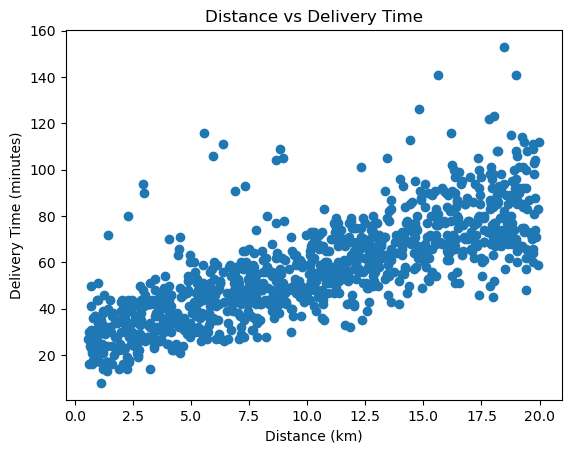

In [18]:
plt.scatter(df["Distance_km"],
            df["Delivery_Time_min"])

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.title("Distance vs Delivery Time")

plt.show()

Does Preparation_Time_min appear to be associated with Delivery_Time_min

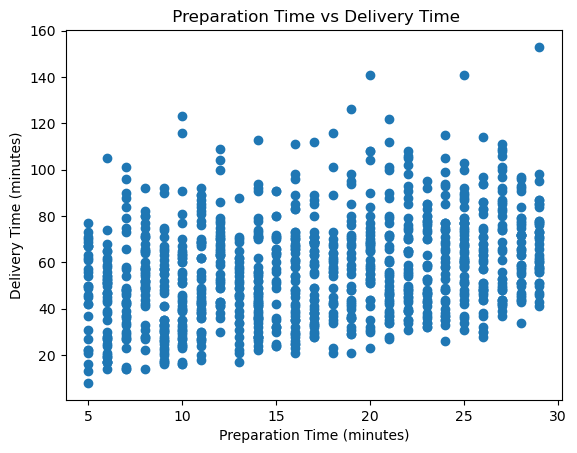

In [19]:
plt.scatter(df["Preparation_Time_min"],
            df["Delivery_Time_min"])

plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")

plt.title(" Preparation Time vs Delivery Time")

plt.show()

Does traffic level appear to be associated with delivery time

In [20]:
Traffic_summary = df.groupby("Traffic_Level", as_index= False).agg(Avg_Delivery_Time =("Delivery_Time_min", "mean") )

Traffic_summary

,Traffic_Level,Avg_Delivery_Time
0,High,64.807107
1,Low,52.885117
2,Medium,56.020513
3,Unknown,62.066667


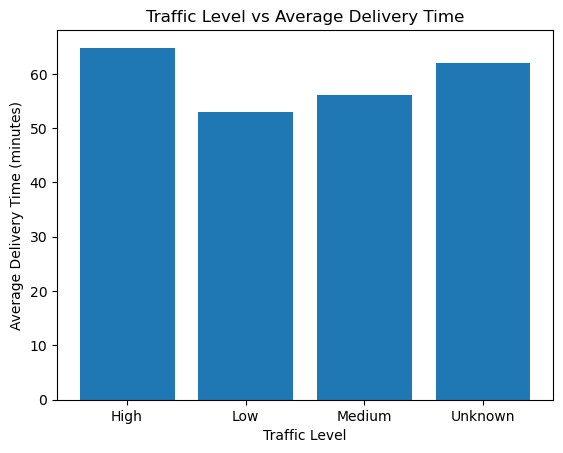

In [21]:
plt.bar(Traffic_summary["Traffic_Level"], 
        Traffic_summary["Avg_Delivery_Time"])

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")

plt.title("Traffic Level vs Average Delivery Time")

plt.show()

Does Weather condition appear to be  associated with delivery time

In [22]:
weather_summary = df.groupby("Weather", as_index= False).agg(Avg_Delivery_Time =("Delivery_Time_min", "mean") )

weather_summary

,Weather,Avg_Delivery_Time
0,Clear,53.082979
1,Foggy,59.466019
2,Rainy,59.794118
3,Snowy,67.113402
4,Unknown,54.200000
5,Windy,55.458333


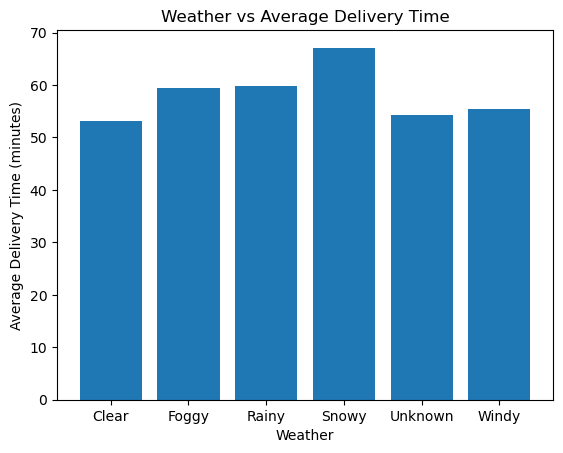

In [23]:
plt.bar(weather_summary["Weather"], 
        weather_summary["Avg_Delivery_Time"])

plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")

plt.title("Weather vs Average Delivery Time")

plt.show()

Does time of dat appear to be associated with delivery time

In [24]:
time_summary = df.groupby("Time_of_Day", as_index= False).agg(Avg_Delivery_Time =("Delivery_Time_min", "mean") )

time_summary

,Time_of_Day,Avg_Delivery_Time
0,Afternoon,56.080986
1,Evening,57.481229
2,Morning,56.120130
3,Night,55.211765
4,Unknown,66.166667


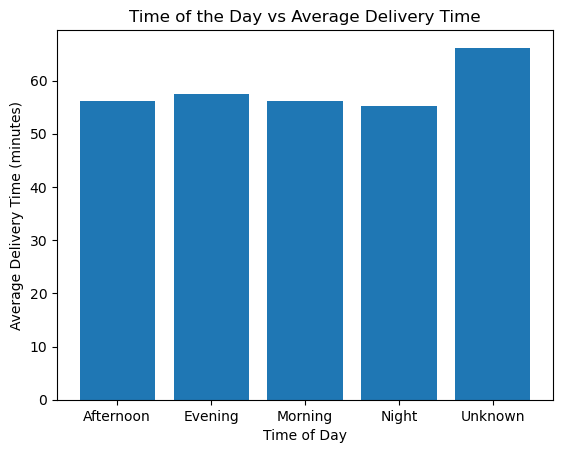

In [25]:
plt.bar(time_summary["Time_of_Day"], 
        time_summary["Avg_Delivery_Time"])

plt.xlabel("Time of Day")
plt.ylabel("Average Delivery Time (minutes)")

plt.title("Time of the Day vs Average Delivery Time")

plt.show()

In [26]:
x = df.drop(["Order_ID","Delivery_Time_min"], axis = 1)
x.shape

(1000, 7)

In [27]:
y = df["Delivery_Time_min"]

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_Train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

x_train.columns
# y_Train.shape
# x_test.shape
# y_test.shape

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs'],
      dtype='object')

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features =[
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]

categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]


preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numerical_features),
                                               ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output = False), categorical_features)])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.fit_transform(x_test)

x_train_processed.shape
x_test_processed.shape

(200, 21)

In [30]:
import tensorflow as tf
from tensorflow.keras  import Sequential
from tensorflow.keras.layers import Dense

# print(tf.keras.__version__)

model = Sequential([Dense(16, activation ="relu", input_shape= (x_train_processed.shape[1],))
                    ,Dense(8,activation = "relu"), 
                    Dense(1)
                    ])

model.summary()



d:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
d:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer ="adam",
    loss = "mse",
    metrics = ["mae"]
)

In [32]:
history = model.fit(
    x_train_processed,
    y_Train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3616.7710 - mae: 55.8829 - val_loss: 3803.8247 - val_mae: 57.7855
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3559.1479 - mae: 55.3981 - val_loss: 3729.5085 - val_mae: 57.1850
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3477.0676 - mae: 54.7074 - val_loss: 3628.2261 - val_mae: 56.3488
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3365.4680 - mae: 53.7332 - val_loss: 3486.0774 - val_mae: 55.1439
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3209.7837 - mae: 52.3581 - val_loss: 3294.3359 - val_mae: 53.4714
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2999.4497 - mae: 50.4359 - val_loss: 3037.9771 - val_mae: 51.1429
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2724.9324 - mae: 47.7861 - val_loss: 2706.0691 - val_mae: 47.9578
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2375.8005 - mae: 44.2231 - val_loss: 2304.5847 - val_mae: 43.8076
E

In [33]:
y_pred = model.predict(x_test_processed).flatten()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [34]:
y_pred[:10]

array([35.002804, 65.30673 , 43.884342, 43.8485  , 84.73111 , 35.842613,
       71.52921 , 33.60913 , 37.208145, 79.20013 ], dtype=float32)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)


Test MAE: 6.277179718017578
Test RMSE: 9.061776388810351
Test R2: 0.8167986273765564
